In [6]:
# Copilot prompt:
# Write code to install and import all necessary libraries for training a YOLO model using Ultralytics in Google Colab.
# Include: ultralytics, torch, matplotlib, gradio.

# Install required packages

# Import necessary libraries
import torch
import torchvision
import matplotlib.pyplot as plt
import gradio as gr
from ultralytics import YOLO
import cv2
import numpy as np
import os
import yaml
from PIL import Image
import random
from pathlib import Path
import ultralytics

print("All libraries installed and imported successfully!")
print(f"Ultralytics version: {ultralytics.__version__ if 'ultralytics' in globals() else 'Not available'}")
print(f"PyTorch version: {torch.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"OpenCV version: {cv2.__version__}")

All libraries installed and imported successfully!
Ultralytics version: 8.3.207
PyTorch version: 2.8.0+cu128
Matplotlib version: 3.10.3
OpenCV version: 4.12.0


In [7]:
# Copilot prompt:
# Add code to check if GPU is available and print device information (CUDA, GPU name, etc).

# Check GPU availability and print device information
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("GPU is not available, using CPU")
    
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Device: cuda
GPU is available: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version: 12.8
Number of GPUs: 1
Current GPU: 0
GPU memory: 6.00 GB
PyTorch version: 2.8.0+cu128
TorchVision version: 0.23.0+cu128


In [8]:
class_labels = {
    0: "coffee_nescafe",
    1: "coffee_kopiko",
    2: "lucky-me-pancit-canton",
    3: "Coke-in-can",
    4: "alaska_milk",
    5: "Century-Tuna",
    6: "VCut-Spicy-Barbeque",
    7: "Selecta-Cornetto",
    8: "nestleyogurt",
    9: "Femme-Bathroom-Tissue",
    10: "maya-champorado",
    11: "jnj-potato-chips",
    12: "Nivea-Deodorant",
    13: "UFC-Canned-Mushroom",
    14: "Libbys-Vienna-Sausage-can",
    15: "Stik-O",
    16: "nissin_cup_noodles",
    17: "dewberry-strawberry",
    18: "Smart-C",
    19: "pineapple-juice-can",
    20: "nestle_chuckie",
    21: "Delight-Probiotic-Drink",
    22: "Summit-Drinking-Water",
    23: "almond_milk",
    24: "Piknik",
    25: "Rambutan",
    26: "head&shoulders_shampoo",
    27: "irish-spring-soap",
    28: "c2_na_green",
    29: "colgate_toothpaste",
    30: "555-sardines-tomato",
    31: "meadows_truffle_chips",
    32: "double-black",
    33: "NongshimCupNoodles"
}

class_names = [name for name in class_labels.values()]
dataset_path = ".././data/mp4/dataset"



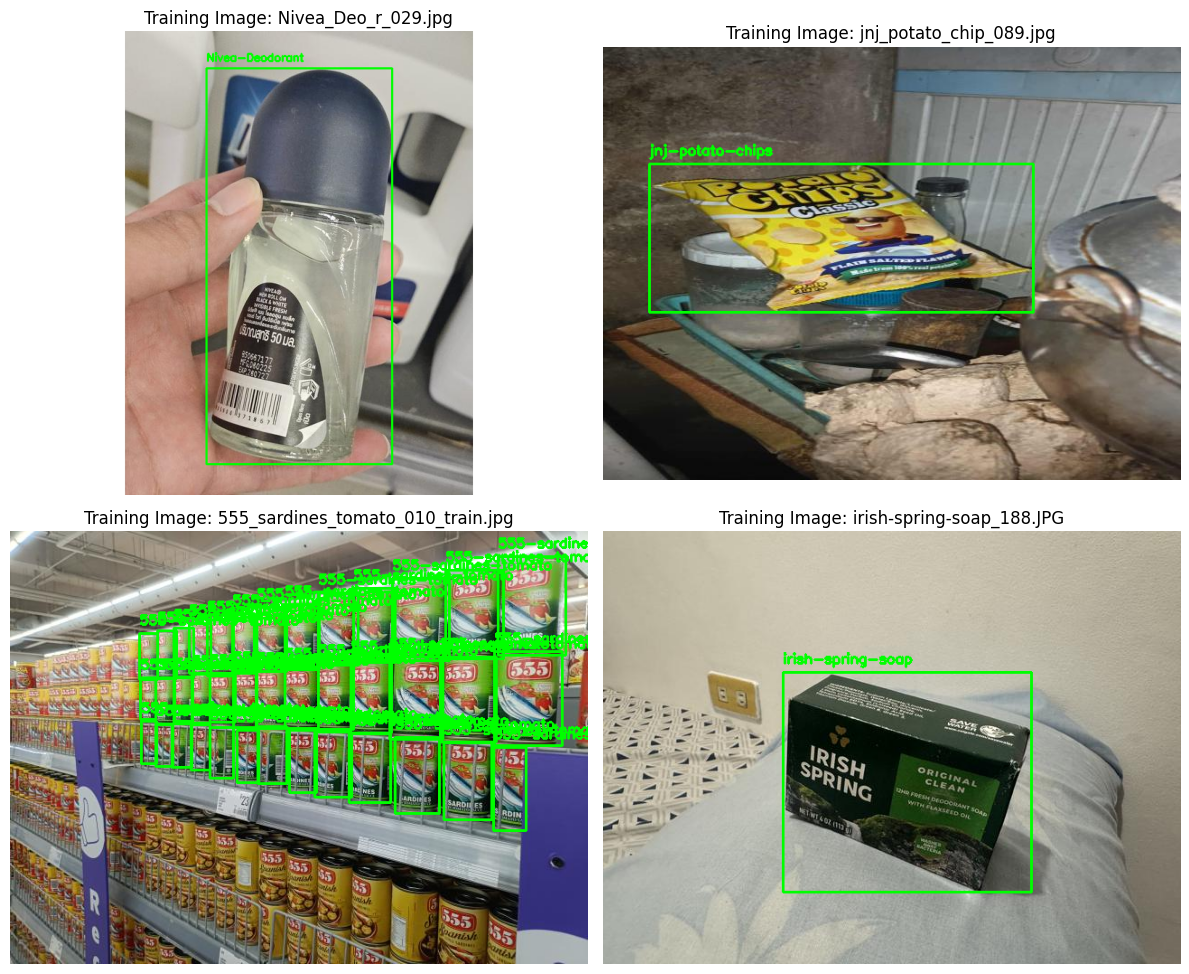

In [9]:
# Copilot prompt:
# Write code to preview random images from the training dataset with their YOLO bounding boxes drawn on top.

def draw_yolo_bboxes(image_path, label_path, class_names):
    """Draw YOLO bounding boxes on image"""
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image.shape
    
    # Load labels if they exist
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    # Convert YOLO format to pixel coordinates
                    x_center *= w
                    y_center *= h
                    width *= w
                    height *= h
                    
                    x1 = int(x_center - width/2)
                    y1 = int(y_center - height/2)
                    x2 = int(x_center + width/2)
                    y2 = int(y_center + height/2)
                    
                    # Draw bounding box
                    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    
                    # Draw class label
                    class_name = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'
                    cv2.putText(image, class_name, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
    return image
# Preview random training images with bounding boxes
train_images_path = f"{dataset_path}/train/images"
train_labels_path = f"{dataset_path}/train/labels"

if os.path.exists(train_images_path) and os.listdir(train_images_path):
    image_files = [f for f in os.listdir(train_images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if image_files:
        # Select random images to display
        num_images = min(4, len(image_files))
        random_images = random.sample(image_files, num_images)
        
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        axes = axes.flatten()
        
        for i, img_file in enumerate(random_images):
            img_path = os.path.join(train_images_path, img_file)
            label_path = os.path.join(train_labels_path, img_file.rsplit('.', 1)[0] + '.txt')
            
            image_with_boxes = draw_yolo_bboxes(img_path, label_path, class_names)
            
            axes[i].imshow(image_with_boxes)
            axes[i].set_title(f'Training Image: {img_file}')
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("No image files found in training directory.")
else:
    print("Training images directory not found or empty.")
    print("Please add images and labels to the training directory to preview them.")

In [10]:
# Copilot prompt:
# Load the latest YOLO model (e.g., yolov11n.pt if available, otherwise yolov8n.pt) using the Ultralytics library.
# Show the model summary.

# Try to load the latest YOLO model

try:
    # Try YOLOv11n first (latest)
    model = YOLO("yolo11n.pt")
    print("Loaded YOLOv11n model successfully!")
except:
    try:
        # Fallback to YOLOv8n
        model = YOLO('yolov8n.pt')
        print("Loaded YOLOv8n model successfully!")
    except:
        print("Error loading YOLO model. Please check your internet connection.")
        model = None

if model is not None:
    # Show model information
    print(f"\nModel architecture: {model.model}")
    print(f"Model task: {model.task}")
    
    # Print model summary
    model.info(detailed=True)
    
    print(f"\nModel loaded successfully and ready for training!")
else:
    print("Failed to load YOLO model.")

Loaded YOLOv11n model successfully!

Model architecture: DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [11]:
# Copilot prompt:
# Train the YOLO model using the dataset in item-1/data.yaml for 100 epochs with image size 640, batch size 16.
# Save results and model weights automatically to the 'runs/train' directory.

if model is not None:
    try:
        # Train the YOLO model
        print("Starting YOLO training...")
        results = model.train(
            data=f"{dataset_path}/data.yaml",
            epochs=100,
            imgsz=640,
            batch=16,
            device=device,
            project='YOLO11N',
            name='train',
            save=True,
            cache=True,
            workers=4,
            patience=50,  # Early stopping patience
            save_period=10,  # Save checkpoint every 10 epochs
        )
        
        print("Training completed successfully!")
        print(f"Results saved to: {results.save_dir}")
        print(f"Best model weights: {results.save_dir}/weights/best.pt")
        print(f"Last model weights: {results.save_dir}/weights/last.pt")
        
        # Store the results for later use
        training_results = results
        
    except Exception as e:
        print(f"Training failed with error: {str(e)}")
        print("Please ensure your dataset has images and labels in the correct directories.")
        training_results = None
else:
    print("Model not loaded. Cannot start training.")
    training_results = None

Starting YOLO training...
New https://pypi.org/project/ultralytics/8.3.208 available  Update with 'pip install -U ultralytics'
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=.././data/mp4/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pa

2025/10/10 10:49:43 INFO mlflow.tracking.fluent: Experiment with name 'YOLO11N' does not exist. Creating a new experiment.


MLflow: logging run_id(914159f2434f459f83defd26cd1bf245) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\MP4_YOLO_TEST2\YOLO11N\train
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100       3.3G     0.9269      3.449      1.184         46        640: 100% ━━━━━━━━━━━━ 1018/1018 5.2it/s 3:14<0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 28/28 2.0it/s 13.8s0.2s
                   all        883       2324      0.707      0.554      0.622      0.502

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100      2.75G     0.9542      1.853      1.181         45        640: 100% ━━

In [20]:
# Copilot prompt:
# After training, evaluate the YOLO model on the test dataset.
# Print metrics such as mAP50, mAP50-95, precision, recall, and overall accuracy.

if 'training_results' in locals() and training_results is not None:
    try:
        # Load the best trained model
        best_model_path = f"{training_results.save_dir}/weights/best.pt"
        trained_model = YOLO(best_model_path)
        
        print("Evaluating the trained model on test dataset...")
        
        # Evaluate on test dataset
        eval_results = trained_model.val(data=f"{dataset_path}/data.yaml")
        
        print("\n" + "="*50)
        print("MODEL EVALUATION RESULTS")
        print("="*50)
        
        # Extract and print key metrics
        if hasattr(eval_results, 'box'):
            metrics = eval_results.box
            print(f"mAP50 (IoU=0.5): {metrics.map50:.4f}")
            print(f"mAP50-95 (IoU=0.5:0.95): {metrics.map:.4f}")
            print(f"Precision: {metrics.mp:.4f}")
            print(f"Recall: {metrics.mr:.4f}")
            
        # Print class-wise metrics if available
        if hasattr(eval_results, 'box') and hasattr(eval_results.box, 'ap_class_index'):
            ap_class_index = eval_results.box.ap_class_index
            if len(ap_class_index) > 0:
                print("\nClass-wise mAP50:")
                # Get the mAP values per class
                maps = eval_results.box.maps  # This gives mAP50 per class
                for i, class_idx in enumerate(ap_class_index):
                    class_name = class_names[class_idx] if class_idx < len(class_names) else f'class_{class_idx}'
                    if i < len(maps):
                        print(f"  {class_name}: {maps[i]:.4f}")
                    else:
                        print(f"  {class_name}: N/A")
        
        print(f"\nEvaluation completed!")
        print(f"Results saved to: {eval_results.save_dir}")
        
    except Exception as e:
        print(f"Evaluation failed: {str(e)}")
        print("Please ensure training was completed successfully.")
        
else:
    print("No trained model found. Please complete training first.")
    print("If you have a pre-trained model, load it using:")
    print("trained_model = YOLO('path/to/your/model.pt')")

Evaluating the trained model on test dataset...
Ultralytics 8.3.207  Python-3.13.7 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
YOLO11n summary (fused): 100 layers, 2,588,782 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 301.5150.6 MB/s, size: 35.0 KB)
val: Scanning C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\data\mp4\dataset\test\labels.cache... 883 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 883/883 1.2Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 56/56 10.9it/s 5.2s0.2s
                   all        883       2324      0.961      0.959       0.98      0.885
        coffee_nescafe         20        135       0.84      0.844      0.899      0.732
         coffee_kopiko         36        181      0.961      0.873      0.977      0.863
Lucky-Me-Pancit-Canton         25         40      0.968      0.975      0.994      0.933
        

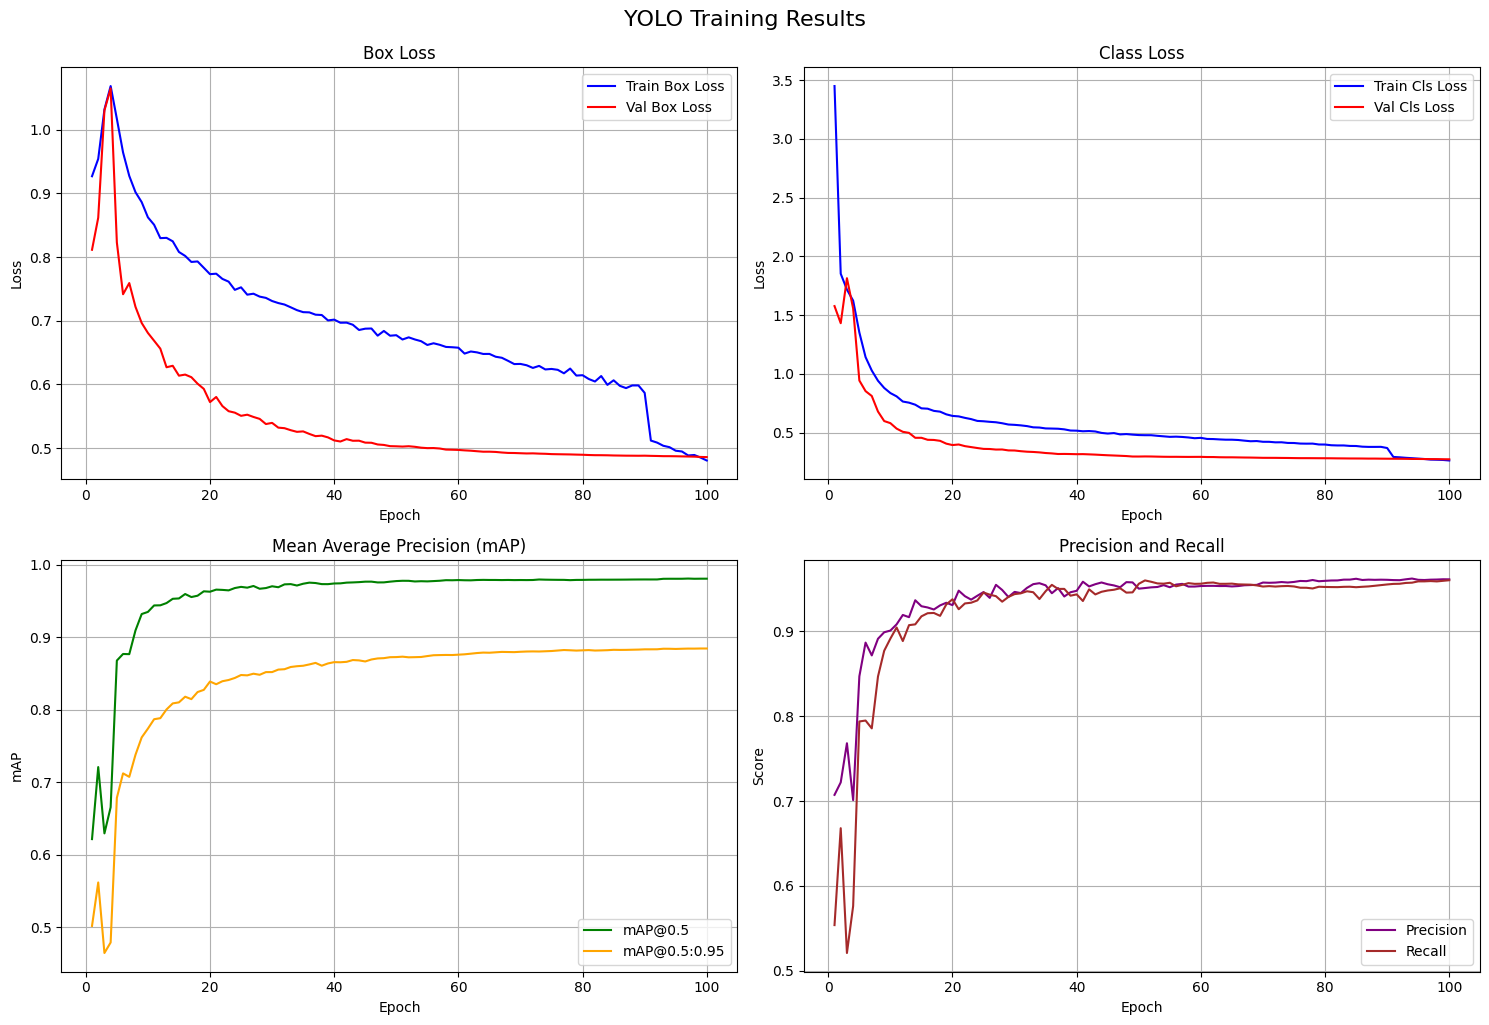


Final Training Statistics:
----------------------------------------


In [29]:
# Copilot prompt:
# Plot YOLO training results including loss curves and mAP using matplotlib from the results file.

if 'training_results' in locals() and training_results is not None:
    try:
        # Path to training results
        results_dir = training_results.save_dir
        results_csv = f"{results_dir}/results.csv"
        
        # Check if results.csv exists
        if os.path.exists(results_csv):
            import pandas as pd
            
            # Read training results
            df = pd.read_csv(results_csv)
            # Clean column names by removing whitespace
            df.columns = df.columns.str.strip()
            
            # Create subplots for different metrics
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # Plot training and validation losses
            if 'train/box_loss' in df.columns:
                axes[0, 0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
                axes[0, 0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='red')
                axes[0, 0].set_title('Box Loss')
                axes[0, 0].set_xlabel('Epoch')
                axes[0, 0].set_ylabel('Loss')
                axes[0, 0].legend()
                axes[0, 0].grid(True)
            
            # Plot objectness loss
            if 'train/cls_loss' in df.columns:
                axes[0, 1].plot(df['epoch'], df['train/cls_loss'], label='Train Cls Loss', color='blue')
                axes[0, 1].plot(df['epoch'], df['val/cls_loss'], label='Val Cls Loss', color='red')
                axes[0, 1].set_title('Class Loss')
                axes[0, 1].set_xlabel('Epoch')
                axes[0, 1].set_ylabel('Loss')
                axes[0, 1].legend()
                axes[0, 1].grid(True)
            
            # Plot mAP scores
            if 'metrics/mAP50(B)' in df.columns:
                axes[1, 0].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@0.5', color='green')
                if 'metrics/mAP50-95(B)' in df.columns:
                    axes[1, 0].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@0.5:0.95', color='orange')
                axes[1, 0].set_title('Mean Average Precision (mAP)')
                axes[1, 0].set_xlabel('Epoch')
                axes[1, 0].set_ylabel('mAP')
                axes[1, 0].legend()
                axes[1, 0].grid(True)
            
            # Plot precision and recall
            if 'metrics/precision(B)' in df.columns and 'metrics/recall(B)' in df.columns:
                axes[1, 1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision', color='purple')
                axes[1, 1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall', color='brown')
                axes[1, 1].set_title('Precision and Recall')
                axes[1, 1].set_xlabel('Epoch')
                axes[1, 1].set_ylabel('Score')
                axes[1, 1].legend()
                axes[1, 1].grid(True)
            
            plt.tight_layout()
            plt.suptitle('YOLO Training Results', y=1.02, fontsize=16)
            plt.show()
            
            # Print final training statistics
            print("\nFinal Training Statistics:")
            print("-" * 40)
            final_epoch = df.iloc[-1]
            if 'metrics/mAP50' in df.columns:
                print(f"Final mAP@0.5: {final_epoch['metrics/mAP50']:.4f}")
            if 'metrics/mAP50-95' in df.columns:
                print(f"Final mAP@0.5:0.95: {final_epoch['metrics/mAP50-95']:.4f}")
            if 'metrics/precision' in df.columns:
                print(f"Final Precision: {final_epoch['metrics/precision']:.4f}")
            if 'metrics/recall' in df.columns:
                print(f"Final Recall: {final_epoch['metrics/recall']:.4f}")
                
        else:
            print(f"Results file not found at: {results_csv}")
            print("Training may not have completed or results file may be in a different location.")
            
    except Exception as e:
        print(f"Error plotting training results: {str(e)}")
        print("Make sure pandas is installed: pip install pandas")
        
else:
    print("No training results found. Please complete training first.")

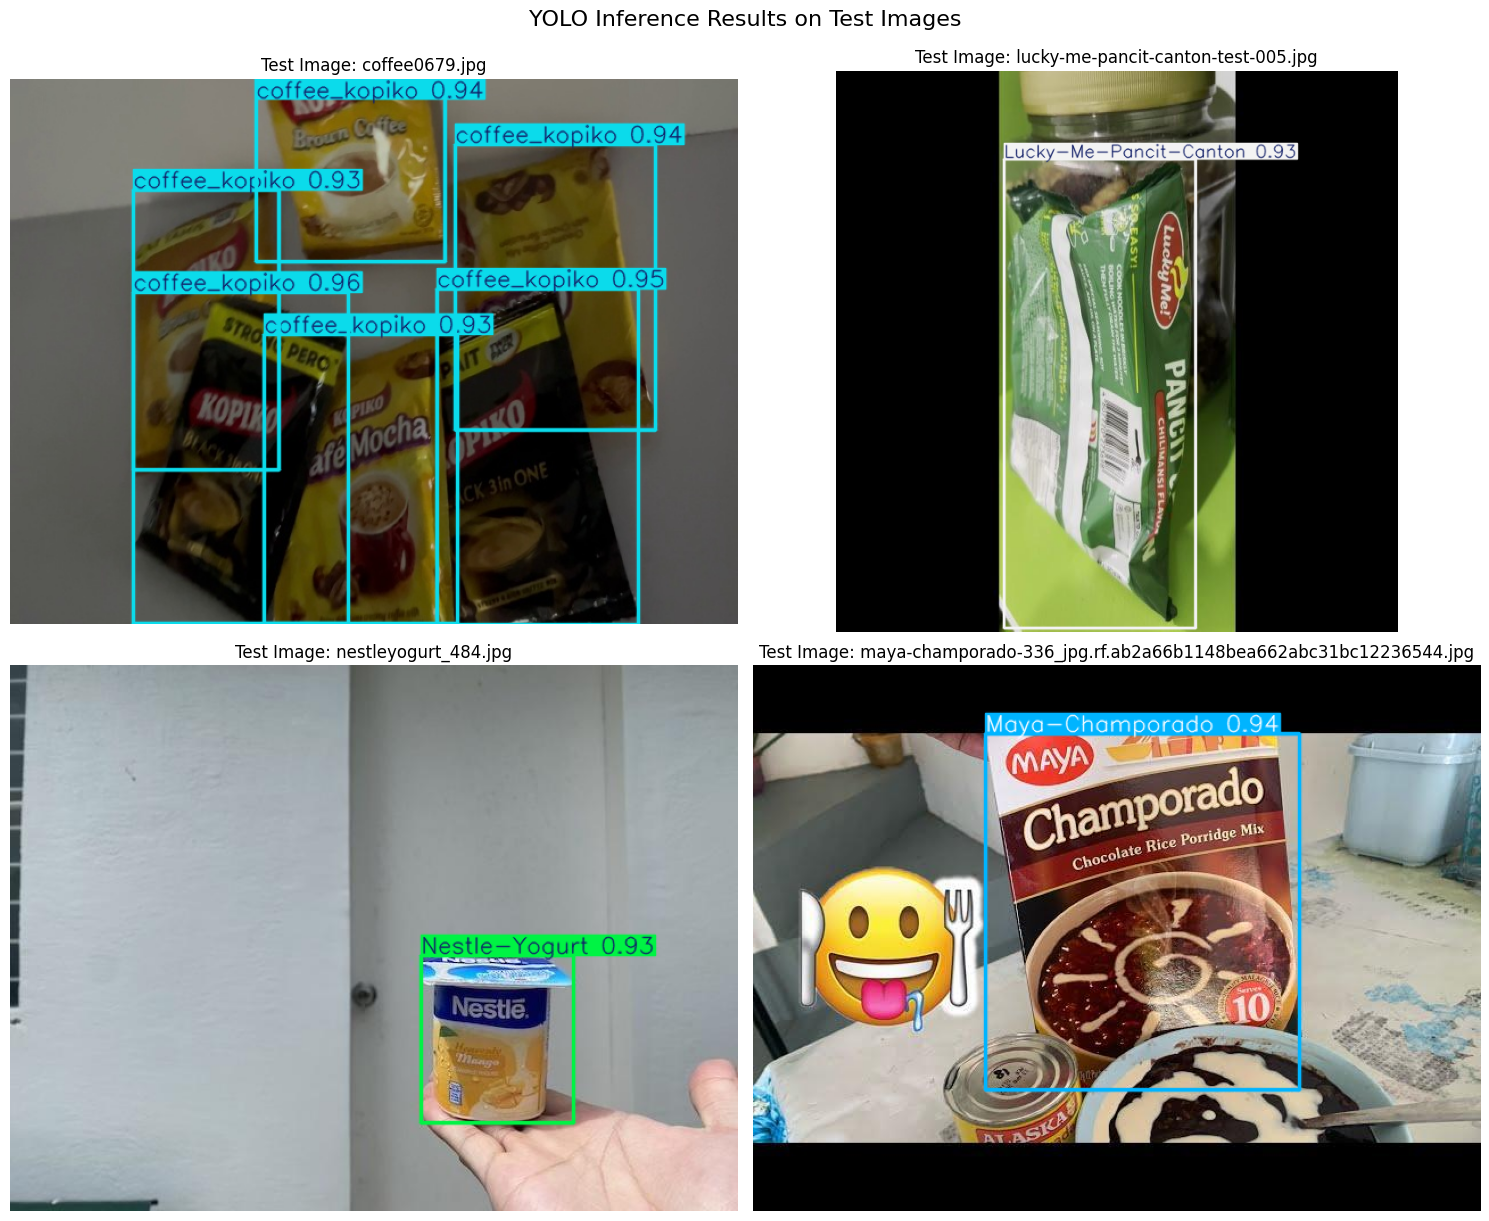

Inference completed on 4 test images.


In [84]:
# Copilot prompt:
# Load several test images and run inference using the trained model.
# Display predicted bounding boxes, class names, and confidence scores.

if 'trained_model' in locals() and trained_model is not None:
    try:
        # Path to test images
        test_images_path = f"{dataset_path}/test/images"
        
        if os.path.exists(test_images_path) and os.listdir(test_images_path):
            image_files = [f for f in os.listdir(test_images_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            
            if image_files:
                # Select random test images
                num_images = min(4, len(image_files))
                random_test_images = random.sample(image_files, num_images)
                
                fig, axes = plt.subplots(2, 2, figsize=(15, 12))
                axes = axes.flatten()
                
                for i, img_file in enumerate(random_test_images):
                    img_path = os.path.join(test_images_path, img_file)
                    
                    # Run inference
                    results = trained_model.predict(img_path, conf=0.25, verbose=False)
                    
                    # Process results
                    if results and len(results) > 0:
                        result = results[0]
                        
                     
                        # Draw predictions
                        plotted_image = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
                       
                    # Display image
                    axes[i].imshow(plotted_image)
                    axes[i].set_title(f'Test Image: {img_file}')
                    axes[i].axis('off')
                
                plt.tight_layout()
                plt.suptitle('YOLO Inference Results on Test Images', y=1.02, fontsize=16)
                plt.show()
                
                print(f"Inference completed on {num_images} test images.")
                
            else:
                print("No image files found in test directory.")
        else:
            print("Test images directory not found or empty.")
            print("Please add test images to run inference.")
            
    except Exception as e:
        print(f"Inference failed: {str(e)}")
        
else:
    print("No trained model available. Please complete training and evaluation first.")
    print("Or load a trained model: trained_model = YOLO('path/to/model.pt')")

In [31]:
# Copilot prompt:
# Export the trained YOLO model to ONNX or TorchScript format for easier deployment if needed.

if 'trained_model' in locals() and trained_model is not None:
    try:
        print("Exporting trained model to different formats...")
        
        # Export to ONNX format
        print("Exporting to ONNX format...")
        onnx_path = trained_model.export(format='onnx', imgsz=640, dynamic=False)
        print(f"ONNX model exported to: {onnx_path}")
        
        # # Export to TorchScript format
        # print("Exporting to TorchScript format...")
        # torchscript_path = trained_model.export(format='torchscript', imgsz=640)
        # print(f"TorchScript model exported to: {torchscript_path}")
        
        # # Export to TensorRT format (if available)
        # try:
        #     print("Attempting to export to TensorRT format...")
        #     tensorrt_path = trained_model.export(format='engine', imgsz=640)
        #     print(f"TensorRT model exported to: {tensorrt_path}")
        # except Exception as e:
        #     print(f"TensorRT export failed (this is normal if TensorRT is not installed): {str(e)}")
        
        # # Export to CoreML format (for Apple devices)
        # try:
        #     print("Attempting to export to CoreML format...")
        #     coreml_path = trained_model.export(format='coreml', imgsz=640)
        #     print(f"CoreML model exported to: {coreml_path}")
        # except Exception as e:
        #     print(f"CoreML export failed (this is normal if coremltools is not installed): {str(e)}")
        
        print("\nModel export completed!")
        print("Available formats:")
        print("- ONNX: Best for general deployment and cross-platform inference")
        print("- TorchScript: Good for PyTorch-based production environments")
        print("- TensorRT: Optimized for NVIDIA GPUs (if available)")
        print("- CoreML: Optimized for Apple devices (if available)")
        
    except Exception as e:
        print(f"Model export failed: {str(e)}")
        print("Make sure the model was trained successfully.")
        
else:
    print("No trained model available for export.")
    print("Please complete training first or load a trained model:")

Exporting trained model to different formats...
Exporting to ONNX format...
Ultralytics 8.3.207  Python-3.13.7 torch-2.8.0+cu128 CPU (Intel Core i5-14450HX)

PyTorch: starting from 'C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\MP4_YOLO_TEST2\YOLO11N\train\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 38, 8400) (5.2 MB)

ONNX: starting export with onnx 1.19.0 opset 22...

PyTorch: starting from 'C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\MP4_YOLO_TEST2\YOLO11N\train\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 38, 8400) (5.2 MB)

ONNX: starting export with onnx 1.19.0 opset 22...
ONNX: slimming with onnxslim 0.1.71...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success  0.7s, saved as 'C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problems\MP4_YOLO_TEST2\YOLO11N\train\weights\best.onnx' (10.1 MB)

Export complete (0.9s)
Results saved to C:\Users\jhon\Desktop\Coding\AI\AI231-machine-problem

In [85]:
# Copilot prompt:
# Build a Gradio app that loads the trained YOLO model and allows users to upload or capture an image.
# The app should return the image with detected bounding boxes and labels drawn on it.
import os

def load_yolo_model():
    model_path = './YOLO11N/train/weights/best.pt'
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at {model_path}")
    return YOLO(model_path)

# Load model when your app starts
try:
    inference_model = load_yolo_model().to(device)
    print("YOLO model loaded successfully")
except Exception as e:
    print(f"Failed to load YOLO model: {e}")
    inference_model = None

    
def yolo_inference(image):
    if inference_model is None:
        return image, "Error: YOLO model not loaded"
    
    if image is None:
        return None, "No image captured"
    
    try:
        # Run inference
        results = inference_model.predict(image, conf=0.25, verbose=False)
        
        if results and len(results) > 0:
            result = results[0]
            plotted_image = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
            # result_image = Image.fromarray(plotted_image[..., ::-1])
            
            if result.boxes is not None and len(result.boxes) > 0:
                detection_info = f"Detected {len(result.boxes)} objects"
            else:
                detection_info = "No objects detected"
                
            return plotted_image, detection_info
        else:
            return image, "No detection results"
            
    except Exception as e:
        return image, f"Error during inference: {str(e)}"
        

# Create Gradio interface with live camera support
def create_gradio_app():
    """Create and return Gradio interface with live camera functionality"""
    
    # Interface description
    description = """
    # AI231 MP4 Object Detection App
    
    **Model:** YOLOv11n trained on MP4 dataset (34 classes) with 100 epochs

    **Multiple Detection Modes:**
    - **Image Upload**: Upload an image file for object detection
    - **Live Camera**: Use your webcam or phone camera for real-time detection
    - **Webcam Capture**: Take a snapshot from your camera for detection
    
    **Features:**
    - Real-time object detection with bounding boxes
    - Class labels and confidence scores
    - Support for webcam and mobile camera access
    - Works on PC, laptop, and mobile devices
    """
    
    # Create tabbed interface for different input methods
    with gr.Blocks(theme=gr.themes.Soft(), title="AI231 MP4 Object Detection") as demo:
        gr.Markdown("# 🎯 AI231 MP4 Object Detection System")
        gr.Markdown(description)
        
        with gr.Tabs():
            # Tab 1: Image Upload
            with gr.Tab("📁 Upload Image"):
                with gr.Row():
                    with gr.Column():
                        upload_input = gr.Image(
                            label="Upload Image", 
                            type="pil",
                            height=400
                        )
                        upload_btn = gr.Button("🔍 Detect Objects", variant="primary")
                    
                    with gr.Column():
                        upload_output = gr.Image(
                            label="Detection Results", 
                            type="pil",
                            height=400
                        )
                        upload_info = gr.Textbox(
                            label="Detection Info",
                            lines=3
                        )
                upload_btn.click(
                    fn=yolo_inference,
                    inputs=[upload_input],
                    outputs=[upload_output, upload_info]
                )
            
            # Tab 2: Live Camera (Real-time)
            with gr.Tab("📹 Live Camera"):
                with gr.Row():
                    with gr.Column():
                        live_input = gr.Image(
                            label="Live Camera Feed",
                            sources=["webcam"],
                            type="pil",
                            height=400,
                            streaming=True  # Enable live streaming
                        )
                    
                    with gr.Column():
                        live_output = gr.Image(
                            label="Live Detection Results",
                            type="pil",
                            height=400
                        )
                        live_info = gr.Textbox(
                            label="Live Detection Info",
                            lines=3
                        )
                
                # Real-time detection on camera input
                live_input.stream(
                    fn=yolo_inference,
                    inputs=[live_input],
                    outputs=[live_output, live_info],
                    show_progress=False,  # Disable progress bar for smoother experience
                    time_limit=10
                )
            
            # Tab 3: Camera Capture (Snapshot)
            with gr.Tab("📸 Camera Capture"):
                with gr.Row():
                    with gr.Column():
                        capture_input = gr.Image(
                            label="Camera Capture",
                            sources=["webcam"],
                            type="pil",
                            height=400
                        )
                        capture_btn = gr.Button("📸 Capture & Detect", variant="primary")
                    
                    with gr.Column():
                        capture_output = gr.Image(
                            label="Capture Detection Results",
                            type="pil",
                            height=400
                        )
                        capture_info = gr.Textbox(
                            label="Capture Detection Info",
                            lines=3
                        )
                
                capture_btn.click(
                    fn=yolo_inference,
                    inputs=[capture_input],
                    outputs=[capture_output, capture_info]
                )
        
        # Add usage instructions
        with gr.Accordion("📋 Usage Instructions", open=False):
            gr.Markdown("""
            ### How to Use:
            
            **Image Upload Tab:**
            - Click "Choose File" to upload an image
            - Click "Detect Objects" to analyze the image
            
            **Live Camera Tab:**
            - Allow camera permissions when prompted
            - Point your camera at objects for real-time detection
            - Detection happens automatically as you move the camera
            
            **Camera Capture Tab:**
            - Allow camera permissions when prompted  
            - Position your camera and click "Capture & Detect"
            - Perfect for taking snapshots for analysis
            
            ### Tips:
            - Ensure good lighting for better detection accuracy
            - Keep objects clearly visible in the camera frame
            - The model detects 34 different product categories
            - Confidence threshold is set to 0.25 (25%)
            """)
    
    return demo

# Create the Gradio app
print("Creating Gradio app...")
gradio_app = create_gradio_app()
print("Gradio app created successfully!")

YOLO model loaded successfully
Creating Gradio app...
Gradio app created successfully!


In [86]:
# Copilot prompt:
# Launch the Gradio demo interface with share=True so that it can be accessed externally.

if 'gradio_app' in locals():
    try:
        print("Launching Gradio interface...")
        print("The interface will be available locally and with a public share link.")
        print("Note: In some environments, you may need to adjust firewall settings.")
        
        # Launch the Gradio app with sharing enabled
        gradio_app.launch(
            share=True,           # Create a public share link
            server_name="0.0.0.0", # Allow external connections
            server_port=7860,     # Default Gradio port
            show_error=True,      # Show errors in the interface
            debug=True,           # Enable debug mode
            inbrowser=True        # Automatically open in browser
        )
        
    except Exception as e:
        print(f"Failed to launch Gradio app: {str(e)}")
        print("Try launching without share: gradio_app.launch(share=False)")
        
        # Fallback: launch without sharing
        try:
            print("Attempting to launch without sharing...")
            gradio_app.launch(share=False, inbrowser=True)
        except Exception as e2:
            print(f"Gradio launch failed completely: {str(e2)}")
            print("Make sure Gradio is properly installed: pip install gradio")
            
else:
    print("Gradio app not found. Please run the previous cell to create the app first.")

Launching Gradio interface...
The interface will be available locally and with a public share link.
Note: In some environments, you may need to adjust firewall settings.
Failed to launch Gradio app: Cannot find empty port in range: 7860-7860. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.
Try launching without share: gradio_app.launch(share=False)
Attempting to launch without sharing...
* Running on local URL:  http://127.0.0.1:7872
* To create a public link, set `share=True` in `launch()`.


Once you complete the prompts above:

YOLOv11 or YOLOv8 model is trained on your dataset.

Evaluation metrics printed: mAP50, mAP50-95, precision, recall.

Bounding box results displayed for visual verification.

Gradio app allows live or uploaded image inference.

All code reproducible in a Colab link for submission.